# Dataset EDA — AutoML Benchmark

Explores all 14 datasets: task type, size, features, class balance, missing values, and target distribution.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

DATASET_DIR = Path("../dataset")

# load all datasets
datasets = []
for folder in sorted(DATASET_DIR.iterdir()):
    if not folder.is_dir(): continue
    if not (folder / "train.csv").exists(): continue
    if not (folder / "meta.json").exists(): continue
    meta = json.loads((folder / "meta.json").read_text())
    df   = pd.read_csv(folder / "train.csv")
    datasets.append({"name": folder.name, "meta": meta, "df": df})

print(f"Loaded {len(datasets)} datasets")


Loaded 11 datasets


## Summary Table

In [2]:
rows = []
for d in datasets:
    df, meta = d["df"], d["meta"]
    label     = meta["label"]
    task      = meta["task"]
    metric    = meta.get("metric", "—")
    drop_cols = meta.get("drop_cols", [])

    X = df.drop(columns=[c for c in [label] + drop_cols if c in df.columns])
    y = df[label]

    n_num = X.select_dtypes(include="number").shape[1]
    n_cat = X.select_dtypes(exclude="number").shape[1]
    missing_pct = df.isnull().mean().mean() * 100

    if task == "classification":
        n_classes   = y.nunique()
        target_info = f"{n_classes} classes"
        imbalance   = y.value_counts(normalize=True).iloc[0] * 100  # majority class %
        balance_str = f"majority {imbalance:.0f}%"
    else:
        n_classes   = "—"
        target_info = f"range [{y.min():.1f}, {y.max():.1f}]"
        balance_str = f"median {y.median():.1f}"

    rows.append({
        "Dataset":      d["name"],
        "Task":         task,
        "Metric":       metric,
        "Rows":         len(df),
        "Features":     X.shape[1],
        "Numeric":      n_num,
        "Categorical":  n_cat,
        "Target":       target_info,
        "Balance":      balance_str,
        "Missing %":    f"{missing_pct:.1f}%",
    })

summary = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 30)
summary


,Dataset,Task,Metric,Rows,Features,Numeric,Categorical,Target,Balance,Missing %
0,abalone,regression,rmse,4177,8,7,1,"range [1.0, 29.0]",median 9.0,0.0%
1,adult_income,classification,auc,32561,13,5,8,2 classes,majority 76%,0.9%
2,breast_cancer,classification,auc,569,30,30,0,2 classes,majority 63%,0.0%
3,california_housing,regression,rmse,20640,8,8,0,"range [0.1, 5.0]",median 1.8,0.0%
4,forest_cover,classification,accuracy,581012,54,54,0,7 classes,majority 49%,0.0%
5,give_me_credit,classification,auc,150000,10,10,0,2 classes,majority 93%,2.0%
6,obesity,classification,accuracy,2111,16,8,8,7 classes,majority 17%,0.0%
7,santander_satisfaction,classification,auc,76020,369,369,0,2 classes,majority 96%,0.0%
8,telco_churn,classification,auc,7043,19,4,15,2 classes,majority 73%,0.0%
9,wine,classification,accuracy,178,13,13,0,3 classes,majority 40%,0.0%


In [ ]:
# Pie chart — problem kind breakdown
from collections import Counter

def problem_kind(row):
    if row["Task"] == "regression":
        return "Regression"
    # infer binary vs multiclass from Target column
    n = int(row["Target"].split()[0]) if row["Target"][0].isdigit() else 2
    return "Binary Classification" if n == 2 else "Multiclass Classification"

summary["Problem Kind"] = summary.apply(problem_kind, axis=1)
counts = Counter(summary["Problem Kind"])

labels = list(counts.keys())
sizes  = list(counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.0f}%\n({int(round(p*sum(sizes)/100))})",
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Dataset Distribution by Problem Type", fontsize=13, pad=16)
plt.tight_layout()
plt.show()


## Dataset Size & Feature Count

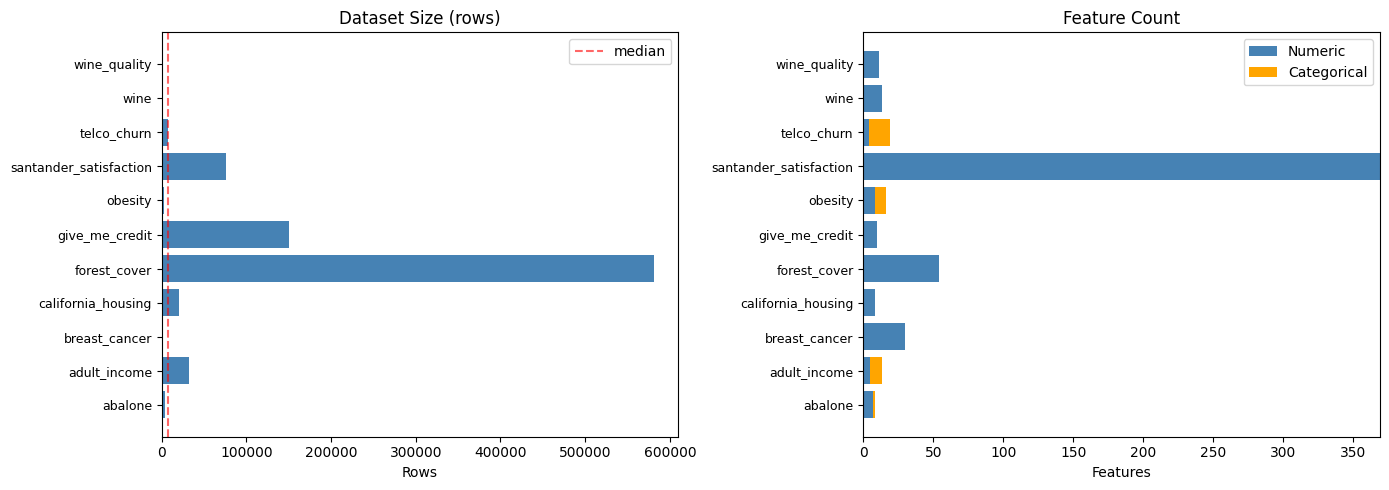

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

names = summary["Dataset"]
x     = np.arange(len(names))

# rows
axes[0].barh(x, summary["Rows"], color="steelblue")
axes[0].set_yticks(x); axes[0].set_yticklabels(names, fontsize=9)
axes[0].set_xlabel("Rows"); axes[0].set_title("Dataset Size (rows)")
axes[0].axvline(summary["Rows"].median(), color="red", linestyle="--", alpha=0.6, label="median")
axes[0].legend()

# features (stacked numeric + categorical)
axes[1].barh(x, summary["Numeric"],     color="steelblue",  label="Numeric")
axes[1].barh(x, summary["Categorical"], left=summary["Numeric"], color="orange", label="Categorical")
axes[1].set_yticks(x); axes[1].set_yticklabels(names, fontsize=9)
axes[1].set_xlabel("Features"); axes[1].set_title("Feature Count")
axes[1].legend()

plt.tight_layout()
plt.show()


## Per-Dataset Detail: Target Distribution & Missing Values

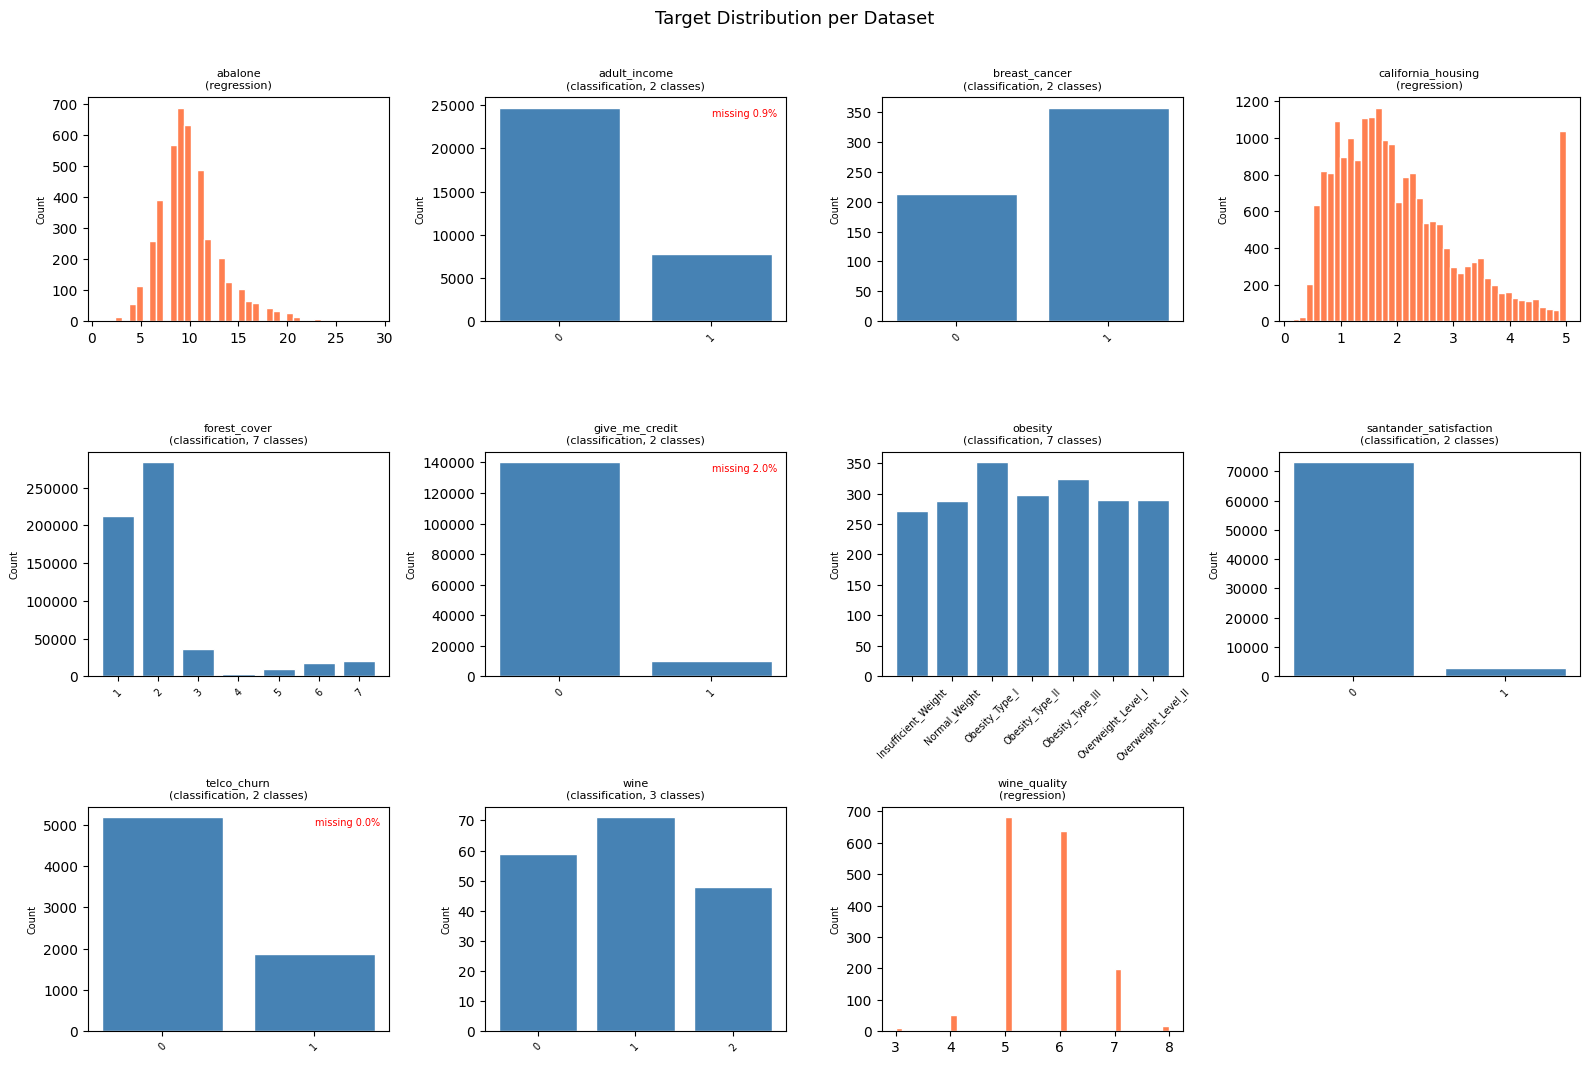

In [4]:
n_cols  = 4
n_rows  = int(np.ceil(len(datasets) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()

for i, d in enumerate(datasets):
    ax   = axes[i]
    df   = d["df"]
    meta = d["meta"]
    y    = df[meta["label"]]
    task = meta["task"]
    name = d["name"]

    if task == "classification":
        counts = y.value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="white")
        ax.set_title(f"{name}\n({task}, {y.nunique()} classes)", fontsize=8)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
    else:
        ax.hist(y.dropna(), bins=40, color="coral", edgecolor="white")
        ax.set_title(f"{name}\n({task})", fontsize=8)

    # missing values annotation
    missing = df.isnull().mean().mean() * 100
    if missing > 0:
        ax.annotate(f"missing {missing:.1f}%", xy=(0.97, 0.95),
                    xycoords="axes fraction", ha="right", va="top",
                    fontsize=7, color="red")

    ax.set_ylabel("Count", fontsize=7)

# hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Target Distribution per Dataset", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Missing Values Heatmap (per dataset × feature)

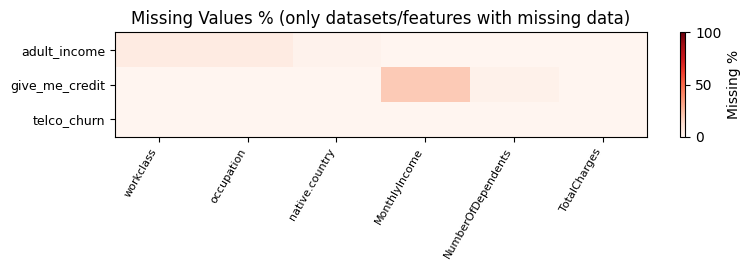

In [5]:
# datasets that have any missing values
missing_rows = []
for d in datasets:
    df   = d["df"]
    pcts = df.isnull().mean() * 100
    pcts = pcts[pcts > 0]
    if not pcts.empty:
        missing_rows.append({"dataset": d["name"], **pcts.to_dict()})

if missing_rows:
    miss_df = pd.DataFrame(missing_rows).set_index("dataset").fillna(0)
    fig, ax = plt.subplots(figsize=(max(8, len(miss_df.columns) * 0.5), len(miss_df) * 0.6 + 1))
    im = ax.imshow(miss_df.values, aspect="auto", cmap="Reds", vmin=0, vmax=100)
    ax.set_xticks(range(len(miss_df.columns))); ax.set_xticklabels(miss_df.columns, rotation=60, ha="right", fontsize=8)
    ax.set_yticks(range(len(miss_df))); ax.set_yticklabels(miss_df.index, fontsize=9)
    plt.colorbar(im, ax=ax, label="Missing %")
    ax.set_title("Missing Values % (only datasets/features with missing data)")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values in any dataset.")


## Feature Statistics per Dataset

In [6]:
for d in datasets:
    df, meta = d["df"], d["meta"]
    label     = meta["label"]
    drop_cols = meta.get("drop_cols", [])
    X = df.drop(columns=[c for c in [label] + drop_cols if c in df.columns])

    print(f"\n{'='*60}")
    print(f"  {d['name']}  |  {meta['task']}  |  metric={meta.get('metric','?')}  |  label={label}")
    print(f"  {len(df):,} rows  ×  {X.shape[1]} features")
    print(f"{'='*60}")
    print(X.describe(include="all").T[["count","mean","std","min","max"]].to_string())



  abalone  |  regression  |  metric=rmse  |  label=Rings
  4,177 rows  ×  8 features
                 count      mean       std     min     max
Sex               4177       NaN       NaN     NaN     NaN
Length          4177.0  0.523992  0.120093   0.075   0.815
Diameter        4177.0  0.407881   0.09924   0.055    0.65
Height          4177.0  0.139516  0.041827     0.0    1.13
Whole weight    4177.0  0.828742  0.490389   0.002  2.8255
Shucked weight  4177.0  0.359367  0.221963   0.001   1.488
Viscera weight  4177.0  0.180594  0.109614  0.0005    0.76
Shell weight    4177.0  0.238831  0.139203  0.0015   1.005

  adult_income  |  classification  |  metric=auc  |  label=income
  32,561 rows  ×  13 features
                  count         mean          std   min      max
age             32561.0    38.581647    13.640433  17.0     90.0
workclass         30725          NaN          NaN   NaN      NaN
education         32561          NaN          NaN   NaN      NaN
education.num   32561.0   

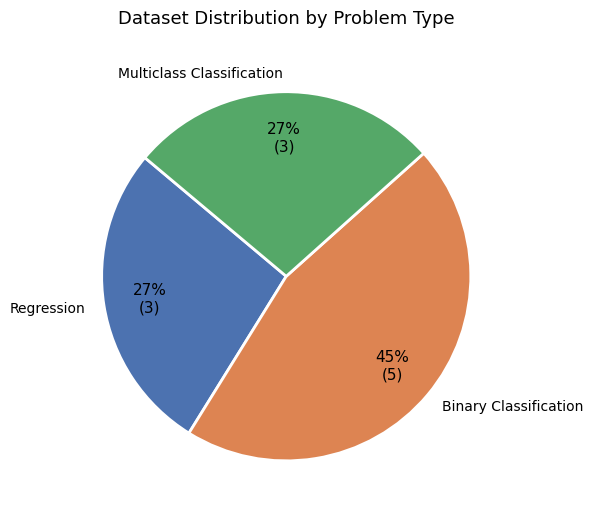

In [7]:
# Pie chart — problem kind breakdown
from collections import Counter

def problem_kind(row):
    if row["Task"] == "regression":
        return "Regression"
    # infer binary vs multiclass from Target column
    n = int(row["Target"].split()[0]) if row["Target"][0].isdigit() else 2
    return "Binary Classification" if n == 2 else "Multiclass Classification"

summary["Problem Kind"] = summary.apply(problem_kind, axis=1)
counts = Counter(summary["Problem Kind"])

labels = list(counts.keys())
sizes  = list(counts.values())
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct=lambda p: f"{p:.0f}%\n({int(round(p*sum(sizes)/100))})",
    startangle=140, pctdistance=0.75,
    wedgeprops=dict(edgecolor="white", linewidth=2),
)
for t in autotexts:
    t.set_fontsize(11)
ax.set_title("Dataset Distribution by Problem Type", fontsize=13, pad=16)
plt.tight_layout()
plt.show()